In [6]:
from wikidata_dataset_class import GlobalTemporalTextKGDataset

# dummy args. Not used if the dataset already esits
dataset = GlobalTemporalTextKGDataset(
    start_year=0,
    json_filename="",
    dataset_filename="simple_dataset_1800.pt",
    root="data/wikidata",
    entity_to_id={},     # not used if already processed
    relation_to_id={},   # not used if already processed
    embed_fn=lambda x: None
)

In [7]:
g = dataset[0]

print("Year:", g.year.item())
print("Edges:", g.edge_index.shape)

Year: 1800
Edges: torch.Size([2, 610])


In [8]:
edge_index = g.edge_index
edge_type = g.edge_type

for i in range(min(10, edge_index.size(1))):
    h = edge_index[0, i].item()
    t = edge_index[1, i].item()
    r = edge_type[i].item()

    h_text = dataset.id_to_entity[h]
    t_text = dataset.id_to_entity[t]
    r_text = dataset.id_to_rel[r]

    print(f"{h_text} --({r_text})-> {t_text}")

Osny --(located in the administrative territorial entity)-> Seine-et-Oise
Rolleboise --(located in the administrative territorial entity)-> Seine-et-Oise
Duchcov --(country)-> Habsburg monarchy
Tikhvin --(country)-> Russian Empire
Bruley --(located in the administrative territorial entity)-> Meurthe
Trévenans --(located in the administrative territorial entity)-> Haut-Rhin
Boucq --(located in the administrative territorial entity)-> Meurthe
Carrières-sous-Poissy --(located in the administrative territorial entity)-> Seine-et-Oise
Villeneuve-Saint-Georges --(located in the administrative territorial entity)-> Seine-et-Oise
Francheville --(located in the administrative territorial entity)-> Meurthe


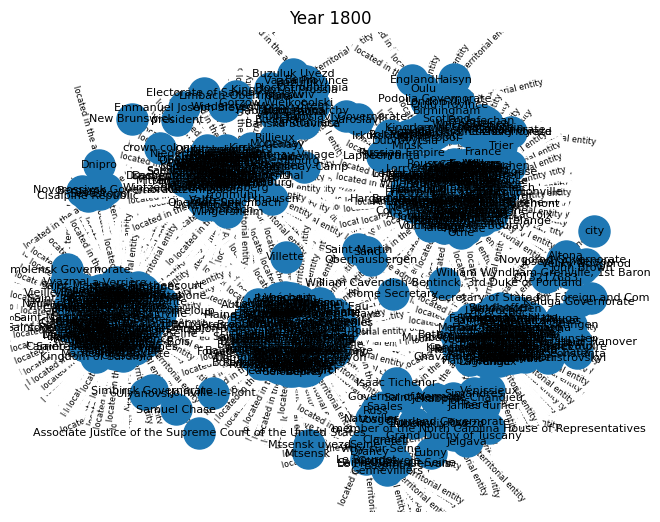

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for i in range(g.edge_index.size(1)):
    h = g.edge_index[0, i].item()
    t = g.edge_index[1, i].item()
    r = g.edge_type[i].item()

    h_text = dataset.id_to_entity[h]
    t_text = dataset.id_to_entity[t]
    r_text = dataset.id_to_rel[r]

    G.add_edge(h_text, t_text, label=r_text)

pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, node_size=500, font_size=8)

edge_labels = nx.get_edge_attributes(G, "label")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.title(f"Year {g.year.item()}")
plt.show()

In [10]:
x = dataset.x_global
print(x)

tensor([[-0.0646,  0.1291, -0.0176,  ..., -0.0426,  0.0009,  0.0244],
        [-0.0383, -0.0623, -0.0585,  ..., -0.1024, -0.0198,  0.0141],
        [-0.0384,  0.0796, -0.0253,  ..., -0.0311,  0.0534,  0.0306],
        ...,
        [-0.0240,  0.0756, -0.0255,  ..., -0.0291,  0.0225,  0.0322],
        [-0.0799,  0.0529, -0.1436,  ..., -0.0803,  0.0158, -0.0169],
        [-0.0941,  0.0429, -0.0338,  ..., -0.0397,  0.0396,  0.0481]])


In [ ]:
# toy model
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import RGCNConv


class SimpleRGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_relations):
        super().__init__()
        self.conv1 = RGCNConv(in_dim, hidden_dim, num_relations=num_relations)
        self.conv2 = RGCNConv(hidden_dim, out_dim, num_relations=num_relations)

    # forward takes global nodes_set, edge indexes, and edge types
    def forward(self, x, edge_index, edge_type):
        x = self.conv1(x, edge_index, edge_type)
        x = F.relu(x)
        x = self.conv2(x, edge_index, edge_type)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# get global nodes set
x = dataset.x_global.to(device)
g = dataset[0].to(device)

# get relation number
num_relations = len(dataset.id_to_rel)

# define model
model = SimpleRGCN(
    in_dim=x.size(1),
    hidden_dim=128,
    out_dim=64,
    num_relations=num_relations,
).to(device)

# example passing data
with torch.no_grad():
    node_embeddings = model(x, g.edge_index, g.edge_type) # global node set, edge_index, edge_type

print("Output node embedding shape:", node_embeddings.shape)

Output node embedding shape: torch.Size([10834, 64])


In [14]:
active_node_embeddings = node_embeddings[g.active_nodes]
print("Active node embedding shape:", active_node_embeddings.shape)

Active node embedding shape: torch.Size([638, 64])
